#Import Modules

In [ ]:
!pip install transformers datasets torch scikit-learn pandas

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,

    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#Load Data

In [ ]:
!unzip -q webmd-reviews-for-diabetes-drugs.zip

In [ ]:
# load data

reviews_file = 'diabetes_drug_webmd_reviews.csv'

col_descripts_file = 'column_descriptions.csv'

df = pd.read_csv(reviews_file)

print(df.head())
print(df.columns)


   Unnamed: 0       drug_name        date    age  gender  \
0           0  Glipizide Oral   2/18/2024  65-74    Male   
1           1  Glipizide Oral   1/29/2024  55-64  Female   
2           2  Glipizide Oral  11/19/2023  65-74    Male   
3           3  Glipizide Oral    7/7/2022  45-54    Male   
4           4  Glipizide Oral    4/1/2022    NaN    Male   

              time_on_drug reviewer_type                 condition  \
0  5 to less than 10 years       Patient  Type 2 Diabetes Mellitus   
1                      NaN       Patient  Type 2 Diabetes Mellitus   
2            1 to 6 months       Patient  Type 2 Diabetes Mellitus   
3            1 to 6 months       Patient  Type 2 Diabetes Mellitus   
4            1 to 6 months       Patient  Type 2 Diabetes Mellitus   

   rating_overall  rating_effectiveness  rating_ease_of_use  \
0             5.0                     5                   5   
1             5.0                     5                   5   
2             2.3            

In [ ]:
print(max(df['rating_satisfaction']))

5


#Cleaning Data

In [ ]:
df = df[['text', 'rating_satisfaction']]

# remove nulls
df = df.dropna()

# convert to string
df['text'] = df['text'].astype(str)

# remove duplicates
df = df.drop_duplicates()

In [ ]:
def create_label(rating):
    if rating >= 3:
        return 1
    return 0

df['label'] = df['rating_satisfaction'].apply(create_label)

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

#Tokenizing

In [ ]:
MODEL_NAME = "bert-base-uncased"


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

#Data Loaders

In [ ]:
class DrugReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(self.labels[idx])

        return item

In [ ]:
train_dataset = DrugReviewDataset(train_encodings, train_labels)
val_dataset = DrugReviewDataset(val_encodings, val_labels)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

#Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:

optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.01
)
EPOCHS = 3

num_training_steps = EPOCHS * len(train_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

#Train and Eval

In [ ]:
from sklearn.metrics import accuracy_score

EPOCHS = 3
best_val_loss = float('inf')
patience = 2
patience_counter = 0
for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================

    model.train()

    train_loss = 0
    train_preds = []
    train_labels_all = []

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

        loss.backward()

        optimizer.step()
        scheduler.step()

    train_acc = accuracy_score(train_labels_all, train_preds)

    avg_train_loss = train_loss / len(train_loader)

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0
    val_preds = []
    val_labels_all = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels_all.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels_all, val_preds)
    if val_loss < best_val_loss:
        model.save_pretrained("best_model")
        best_val_loss = val_loss
        patience_counter = 0

    else:
        patience_counter += 1
        if patience_counter >= patience:
          print("Early stopping trigggred")
          break
    avg_val_loss = val_loss / len(val_loader)

    # =========================
    # PRINT RESULTS
    # =========================

    print(f"Epoch {epoch+1} phase 1")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    print("-" * 40)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 phase 1
Train Loss: 0.5067
Train Accuracy: 0.7482
Val Loss: 0.4019
Val Accuracy: 0.8161
----------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2 phase 1
Train Loss: 0.3460
Train Accuracy: 0.8477
Val Loss: 0.3992
Val Accuracy: 0.8194
----------------------------------------
Epoch 3 phase 1
Train Loss: 0.2685
Train Accuracy: 0.8932
Val Loss: 0.4149
Val Accuracy: 0.8265
----------------------------------------


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "best_model"
)
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
optimizer = AdamW(
    model.parameters(),
    lr=5e-6,
    weight_decay=0.01
)

In [ ]:
from sklearn.metrics import accuracy_score

EPOCHS = 6
patience = 2
best_val_loss = float('inf')
patience_counter = 0
for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================

    model.train()

    train_loss = 0
    train_preds = []
    train_labels_all = []

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

        loss.backward()

        optimizer.step()
        scheduler.step()

    train_acc = accuracy_score(train_labels_all, train_preds)

    avg_train_loss = train_loss / len(train_loader)

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0
    val_preds = []
    val_labels_all = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels_all.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels_all, val_preds)
    if val_loss < best_val_loss:
        model.save_pretrained("best_model")
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
          print("Early stopping trigggred")
          break
    avg_val_loss = val_loss / len(val_loader)

    # =========================
    # PRINT RESULTS
    # =========================

    print(f"Epoch {epoch+1} phase 2")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    print("-" * 40)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 phase 2
Train Loss: 0.2688
Train Accuracy: 0.8919
Val Loss: 0.4078
Val Accuracy: 0.8245
----------------------------------------
Epoch 2 phase 2
Train Loss: 0.2045
Train Accuracy: 0.9227
Val Loss: 0.4702
Val Accuracy: 0.8187
----------------------------------------
Early stopping trigggred


In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    "best_model"
)
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

#Inference

In [ ]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(true_labels, predictions)

print("Accuracy:", accuracy)

print(classification_report(true_labels, predictions))

Accuracy: 0.824516129032258
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       625
           1       0.87      0.84      0.85       925

    accuracy                           0.82      1550
   macro avg       0.82      0.82      0.82      1550
weighted avg       0.83      0.82      0.83      1550



In [ ]:
text = "This medicine has no side effects."

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

if prediction == 1:
    print("Positive Review")
else:
    print("Negative Review")


Positive Review


#Explainable AI

In [ ]:
def predict_fn(texts):

    if isinstance(texts, str):
        texts = [texts]

    texts = [str(t) for t in texts]

    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)

    return probs.cpu().numpy()

In [ ]:
import shap

texts = [val_texts[0]]

masker = shap.maskers.Text(tokenizer)

explainer = shap.Explainer(
    predict_fn,
    masker=masker
)

shap_values = explainer(texts)

shap.plots.text(shap_values)

In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    "best_model",
    output_attentions =True
)
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

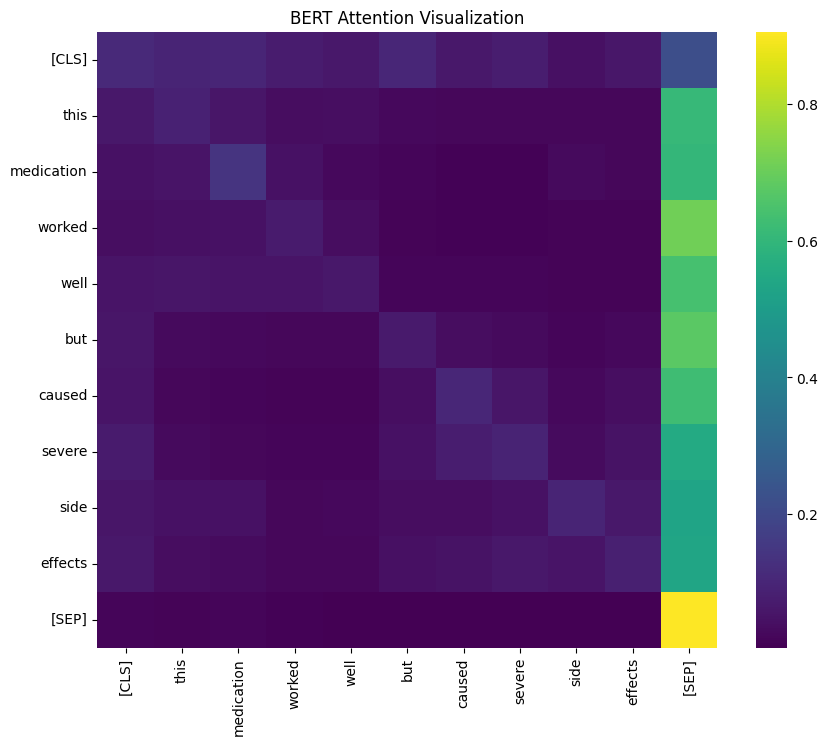

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

# Load pretrained BERT

model.eval()

# -----------------------------
# Input Text
# -----------------------------
text = "This medication worked well but caused severe side effects"

inputs = tokenizer(text, return_tensors="pt")

# -----------------------------
# Get Attention Weights
# -----------------------------
inputs.to(device)
with torch.no_grad():
    outputs = model(**inputs,output_attentions=True)


attentions = outputs.attentions  # tuple of layers

# Select last layer attention
last_layer_attention = attentions[-1]

# Shape: (batch, heads, tokens, tokens)
attention = last_layer_attention[0]  # first sample

# Average across heads
attention_mean = attention.mean(dim=0)

# -----------------------------
# Convert tokens
# -----------------------------
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# -----------------------------
# Plot Heatmap
# -----------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(attention_mean.cpu().numpy(), xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("BERT Attention Visualization")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()